# LEDT Prototype — Integrating NASA TEMPO into NVIDIA Earth-2

**Smithsonian Living Earth Digital Twin** · feedback-layer prototype notebook.  
PI: Grant Tremblay (SAO) · Co-Is: McCarthy, Smith, Garraffo, Nowlan (SAO); Nowakowski, Megonigal, Rich (SERC); Torchin, Sanjur (STRI).

---

## What this notebook does

This is a **minimum-viable, runnable prototype** of one slice of the Living Earth Digital Twin (LEDT) concept:

1. Fetches a real NASA **TEMPO L3 NO₂ tropospheric column** granule from NASA Earthdata.
2. Loads it as an `xarray.Dataset` and visualizes it over North America.
3. Wraps it in an **earth2studio-compatible diagnostic model** — the same API used by `CorrDiff`, `PrecipitationAFNO`, etc. — so that TEMPO can be treated as just another *diagnostic layer* inside an Earth-2 pipeline.
4. Sketches the **TEMPO → LEDT → ecological response** linkage using a toy SERC-wetland site response model. This is not science; it is an API placeholder.
5. Shows how the diagnostic would plug into a real `earth2studio.run.diagnostic` workflow.

## Do I need an NVIDIA GPU?

**Not for this notebook.** Everything here runs on CPU. We deliberately avoid loading any large pretrained Earth-2 model in this demo and instead stub the interface.

For the *actual* Earth-2 pipeline — FourCastNet3, GraphCast, cBottle, CorrDiff — you will want an NVIDIA GPU. NVIDIA's recommended baseline is compute capability ≥ 8.9 (L40S / A6000 / H100) with ≥ 40 GB VRAM. Many smaller models will still run on more modest GPUs; a subset will even run on CPU but slowly. The Earth2Studio docs are explicit: *"if PyTorch can run, then many features of Earth2Studio should run as well,"* but **inference-quality results at scale require a GPU**.

For early LEDT development — data wrangling, ingest, custom diagnostic authoring, CorrDiff-Bio prototyping on small domains — your Mac is fine. For production runs, we'd lean on NSF ACCESS / Perlmutter / a cloud H100 pool, or on whatever NVIDIA partners lend us through the Earth-2 collaboration.


## 0 · Setup

Install dependencies. We keep this lean — no earth2studio install required for the demo path, but we mirror its API. Uncomment the second block if you want the real earth2studio in your env.


In [1]:
# Minimal deps for this notebook:
# pip install numpy xarray netcdf4 matplotlib cartopy requests
# pip install earthaccess  # NASA Earthdata auth + search

# Optional (for the *real* Earth-2 pipeline at the end):
# pip install "earth2studio @ git+https://github.com/NVIDIA/earth2studio.git"

import os
import json
import warnings
from collections import OrderedDict
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

DATA_DIR = Path("./tempo_data")
DATA_DIR.mkdir(exist_ok=True)
print(f"Working directory: {DATA_DIR.resolve()}")

Working directory: /Users/grant/Repositories/earth_digital_twin/notebooks/tempo_data


## 1 · Fetch a TEMPO L3 NO₂ granule

The TEMPO (Tropospheric Emissions: Monitoring of Pollution) instrument — the SAO-led geostationary air-quality sensor — provides hourly measurements of NO₂, O₃, HCHO, aerosols, and solar-induced chlorophyll fluorescence (SIF) across North America.

TEMPO data are hosted at NASA's [Atmospheric Science Data Center (ASDC)](https://asdc.larc.nasa.gov/project/TEMPO). We'll use `earthaccess` to search and download a single L3 NO₂ file.

> **Auth**: you will need a free NASA Earthdata login (https://urs.earthdata.nasa.gov). On first run `earthaccess` will prompt for credentials and cache them. For CI / headless use, set `EARTHDATA_USERNAME` and `EARTHDATA_PASSWORD` env vars.


In [2]:
def fetch_tempo_no2(start="2024-08-15", end="2024-08-15"):
    """Download one TEMPO L3 NO2 tropospheric-column granule.

    Returns path to a local netCDF4 file, or None if Earthdata is unreachable
    (in which case we'll fall back to a synthetic TEMPO-like dataset so the
    rest of the notebook still runs offline).
    """
    try:
        import earthaccess
        earthaccess.login(persist=True)
        # TEMPO L3 NO2 tropospheric column v3 (short_name used by ASDC)
        results = earthaccess.search_data(
            short_name="TEMPO_NO2_L3",
            temporal=(start, end),
            count=1,
        )
        if not results:
            print("No granules found — check date range / collection name.")
            return None
        files = earthaccess.download(results, local_path=str(DATA_DIR))
        return files[0] if files else None
    except Exception as e:
        print(f"[earthaccess unavailable] {e!r}")
        return None


def synthetic_tempo_no2(date="2024-08-15"):
    """Synthetic TEMPO-like NO2 field over North America for offline demos.

    This is **not** real measurement data — it is a plausible-shaped mock
    used only to keep the notebook runnable without Earthdata access. It
    imitates the spatial character of urban NO2 plumes so that downstream
    code paths (wrapping, plotting, diagnostic API) behave realistically.
    """
    lon = np.linspace(-125, -65, 480)
    lat = np.linspace(15, 55, 320)
    LON, LAT = np.meshgrid(lon, lat)

    # Background column
    field = 0.6e15 + 0.2e15 * np.random.default_rng(42).normal(size=LON.shape)

    # Plume hotspots near major metros
    metros = [
        (40.7, -74.0, 8.0e15),   # NYC
        (34.05, -118.2, 6.5e15), # LA
        (29.76, -95.37, 5.5e15), # Houston
        (41.87, -87.62, 5.0e15), # Chicago
        (33.75, -84.39, 4.0e15), # Atlanta
        (38.90, -77.03, 4.0e15), # DC
        (25.76, -80.19, 3.0e15), # Miami
        (32.71, -117.16, 3.5e15),# San Diego
    ]
    for mlat, mlon, peak in metros:
        d2 = (LAT - mlat) ** 2 + (LON - mlon) ** 2
        field += peak * np.exp(-d2 / 0.35)
    field = np.clip(field, 0, None)

    ds = xr.Dataset(
        data_vars={
            "no2_troposphere": (
                ("lat", "lon"),
                field.astype(np.float32),
                {
                    "units": "molec cm-2",
                    "long_name": "NO2 tropospheric vertical column (synthetic)",
                    "provenance": "SYNTHETIC — not TEMPO measurement",
                },
            )
        },
        coords={"lat": lat, "lon": lon},
        attrs={
            "title": "Synthetic TEMPO-like NO2 L3 mock",
            "time_reference": date,
            "instrument": "TEMPO (mock)",
            "producer": "LEDT notebook — offline fallback",
        },
    )
    return ds


path = fetch_tempo_no2()
if path is not None:
    print(f"Got real TEMPO file: {path}")
    tempo = xr.open_dataset(path, group="product")
else:
    print("Falling back to synthetic TEMPO-like dataset.")
    tempo = synthetic_tempo_no2()
tempo

[earthaccess unavailable] ModuleNotFoundError("No module named 'earthaccess'")
Falling back to synthetic TEMPO-like dataset.


<xarray.Dataset> Size: 621kB
Dimensions:          (lat: 320, lon: 480)
Coordinates:
  * lat              (lat) float64 3kB 15.0 15.13 15.25 ... 54.75 54.87 55.0
  * lon              (lon) float64 4kB -125.0 -124.9 -124.7 ... -65.13 -65.0
Data variables:
    no2_troposphere  (lat, lon) float32 614kB 6.609e+14 3.92e+14 ... 4.526e+14
Attributes:
    title:           Synthetic TEMPO-like NO2 L3 mock
    time_reference:  2024-08-15
    instrument:      TEMPO (mock)
    producer:        LEDT notebook — offline fallback

### Normalize to a common schema

Real TEMPO L3 files carry a richer schema (grouped netCDF, quality flags, column amounts and uncertainties). For Earth-2 integration we only need a 2D field on lat/lon — so here we collapse to a uniform `("no2_troposphere", lat, lon)` variable regardless of source.


In [3]:
def to_ledt_schema(ds: xr.Dataset) -> xr.Dataset:
    """Normalize a TEMPO-ish dataset into a minimal LEDT schema."""
    # Real TEMPO L3: variable is 'vertical_column_troposphere' inside 'product' group
    candidates = [
        "no2_troposphere",
        "vertical_column_troposphere",
        "nitrogendioxide_tropospheric_column",
    ]
    var = next((v for v in candidates if v in ds.data_vars), None)
    if var is None:
        raise ValueError(f"Could not find NO2 variable in {list(ds.data_vars)}")

    lat_name = "latitude" if "latitude" in ds.coords else "lat"
    lon_name = "longitude" if "longitude" in ds.coords else "lon"

    out = xr.Dataset(
        data_vars={"no2_troposphere": ds[var].rename({lat_name: "lat", lon_name: "lon"})}
        if (lat_name != "lat" or lon_name != "lon")
        else {"no2_troposphere": ds[var]},
    )
    return out


tempo = to_ledt_schema(tempo)
print(tempo)

<xarray.Dataset> Size: 621kB
Dimensions:          (lat: 320, lon: 480)
Coordinates:
  * lat              (lat) float64 3kB 15.0 15.13 15.25 ... 54.75 54.87 55.0
  * lon              (lon) float64 4kB -125.0 -124.9 -124.7 ... -65.13 -65.0
Data variables:
    no2_troposphere  (lat, lon) float32 614kB 6.609e+14 3.92e+14 ... 4.526e+14


## 2 · Visualize

A quick sanity-check plot. On real TEMPO data you'll see the familiar urban-plume morphology over the I-95 corridor, LA basin, Houston, Chicago, and the Central Valley.


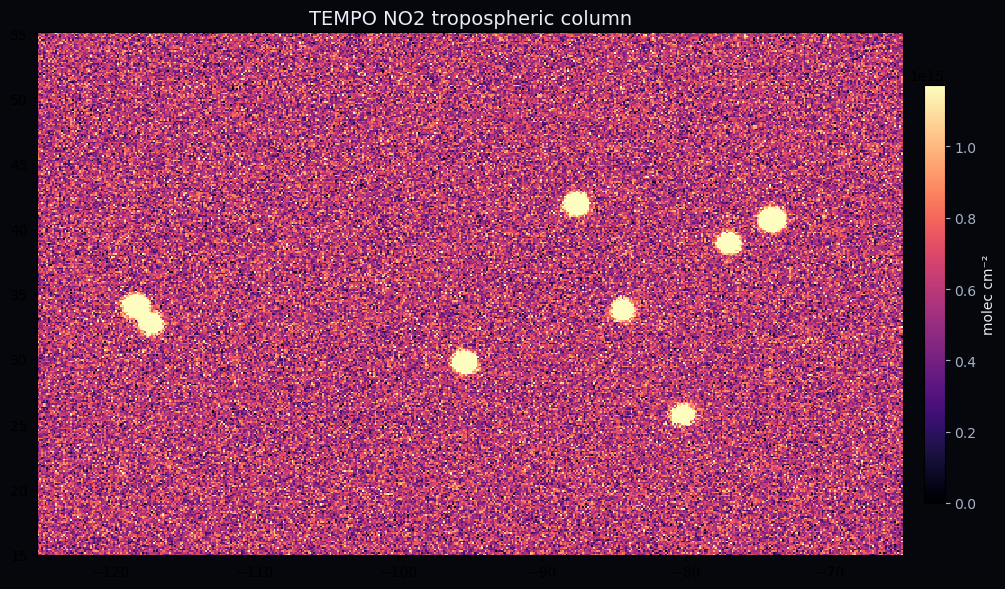

In [4]:
def plot_tempo(ds, title="TEMPO NO2 tropospheric column"):
    try:
        import cartopy.crs as ccrs
        import cartopy.feature as cfeat
        has_cartopy = True
    except Exception:
        has_cartopy = False

    fig = plt.figure(figsize=(11, 6), facecolor="#05070d")
    if has_cartopy:
        ax = plt.axes(projection=ccrs.PlateCarree())
        ax.set_extent([-125, -65, 20, 55], crs=ccrs.PlateCarree())
        ax.add_feature(cfeat.COASTLINE, edgecolor="#6c7691", linewidth=0.5)
        ax.add_feature(cfeat.BORDERS, edgecolor="#6c7691", linewidth=0.4)
        ax.add_feature(cfeat.STATES, edgecolor="#414a61", linewidth=0.3)
    else:
        ax = plt.axes()

    im = ax.pcolormesh(
        ds["lon"], ds["lat"], ds["no2_troposphere"],
        cmap="magma", shading="auto",
        vmin=0, vmax=np.nanpercentile(ds["no2_troposphere"], 99),
        **({"transform": ccrs.PlateCarree()} if has_cartopy else {}),
    )
    cbar = plt.colorbar(im, ax=ax, pad=0.02, shrink=0.8)
    cbar.set_label("molec cm⁻²", color="#e7ecf7")
    cbar.ax.yaxis.set_tick_params(color="#a7b1c4")
    for lbl in cbar.ax.get_yticklabels():
        lbl.set_color("#a7b1c4")
    ax.set_title(title, color="#e7ecf7", fontsize=14)
    plt.tight_layout()
    plt.show()


plot_tempo(tempo)

## 3 · Wrap TEMPO as an earth2studio diagnostic

NVIDIA Earth2Studio defines a **Diagnostic Model** as any class that:

1. Subclasses `torch.nn.Module`.
2. Exposes `input_coords()` and `output_coords(input_coords)` returning an `OrderedDict` of dimension → numpy-array coordinate.
3. Implements `__call__(x, coords) -> (tensor, coords)`.

Any object that satisfies this contract — called a `DiagnosticModel` in the docs — plugs cleanly into `earth2studio.run.diagnostic()` alongside prognostics like FCN3, GraphCast, or Aurora. The pattern is documented in `examples/08_extend/02_custom_diagnostic.py` in the earth2studio repo you cloned.

Here we treat **TEMPO itself** as a diagnostic: given an atmospheric state with surface temperature, UV, and boundary-layer height (e.g. from an Earth-2 prognostic run), it attaches the measured/modeled NO₂ column as a new diagnostic variable. In practice this gives LEDT a uniform way to **fuse orbital observations into Earth-2 outputs** without rebuilding the pipeline.


In [5]:
import torch


class TEMPONO2Diagnostic(torch.nn.Module):
    """TEMPO NO2 as an earth2studio-compatible diagnostic layer.

    Given an input tensor on a lat/lon grid (from any prognostic: FCN3,
    GraphCast, Aurora, cBottle, ...), this diagnostic returns TEMPO NO2
    tropospheric column regridded onto the same grid. Downstream LEDT
    models can then consume it as just another variable.

    This is a *data-fusion* diagnostic rather than a learned model — the
    fancy version is what we will explore during the Innovation Design
    Lab: train a neural operator that predicts ecological response from
    (atmospheric state, TEMPO chemistry) pairs.
    """

    def __init__(self, tempo_ds: xr.Dataset, input_var: str = "t2m"):
        super().__init__()
        self._tempo = tempo_ds
        self._input_var = input_var
        # Standard Earth-2 0.25-degree global grid
        self._lat = np.linspace(90, -90, 721)
        self._lon = np.linspace(0, 360, 1440, endpoint=False)

        # Regrid TEMPO onto the earth2studio global grid once at init time.
        self._no2_on_e2_grid = self._regrid(tempo_ds)

    # ---- earth2studio diagnostic contract ----
    def input_coords(self):
        return OrderedDict(
            batch=np.empty(0),
            variable=np.array([self._input_var]),
            lat=self._lat,
            lon=self._lon,
        )

    def output_coords(self, input_coords):
        out = OrderedDict(
            batch=np.empty(0),
            variable=np.array(["no2_troposphere"]),
            lat=self._lat,
            lon=self._lon,
        )
        out["batch"] = input_coords.get("batch", np.empty(0))
        return out

    def __call__(self, x: torch.Tensor, coords):
        # Ignore prognostic input values (this is a pure fusion layer in the
        # demo) but preserve the batch dim so the pipeline stays composable.
        batch_size = x.shape[0] if x.dim() > 3 else 1
        out = torch.from_numpy(
            np.broadcast_to(
                self._no2_on_e2_grid[None, None, ...],
                (batch_size, 1, self._lat.size, self._lon.size),
            ).copy()
        ).float()
        return out, self.output_coords(coords)

    # ---- regridding helper ----
    def _regrid(self, ds: xr.Dataset) -> np.ndarray:
        """Nearest-neighbor regrid from TEMPO grid → E2 0.25° global grid.

        For a real pipeline prefer xESMF / pyresample / conservative regrid.
        Nearest-neighbor is fine for a demo.
        """
        tempo_lat = ds["lat"].values
        tempo_lon = ds["lon"].values
        # TEMPO longitudes are -180..180; Earth-2 uses 0..360.
        tempo_lon_360 = np.where(tempo_lon < 0, tempo_lon + 360, tempo_lon)

        out = np.full((self._lat.size, self._lon.size), np.nan, dtype=np.float32)
        # Slice the block of E2 grid that TEMPO actually covers
        lat_mask = (self._lat >= tempo_lat.min()) & (self._lat <= tempo_lat.max())
        lon_mask = (self._lon >= tempo_lon_360.min()) & (self._lon <= tempo_lon_360.max())

        sub_lats = self._lat[lat_mask]
        sub_lons = self._lon[lon_mask]

        # Nearest-neighbor indices
        i_idx = np.abs(sub_lats[:, None] - tempo_lat[None, :]).argmin(axis=1)
        j_idx = np.abs(sub_lons[:, None] - tempo_lon_360[None, :]).argmin(axis=1)
        block = ds["no2_troposphere"].values[np.ix_(i_idx, j_idx)]

        out[np.ix_(lat_mask, lon_mask)] = block
        return out


diagnostic = TEMPONO2Diagnostic(tempo)
print("Input coords :", dict(diagnostic.input_coords()))
print("Output coords:", dict(diagnostic.output_coords(diagnostic.input_coords())))

Input coords : {'batch': array([], dtype=float64), 'variable': array(['t2m'], dtype='<U3'), 'lat': array([ 90.  ,  89.75,  89.5 ,  89.25,  89.  ,  88.75,  88.5 ,  88.25,
        88.  ,  87.75,  87.5 ,  87.25,  87.  ,  86.75,  86.5 ,  86.25,
        86.  ,  85.75,  85.5 ,  85.25,  85.  ,  84.75,  84.5 ,  84.25,
        84.  ,  83.75,  83.5 ,  83.25,  83.  ,  82.75,  82.5 ,  82.25,
        82.  ,  81.75,  81.5 ,  81.25,  81.  ,  80.75,  80.5 ,  80.25,
        80.  ,  79.75,  79.5 ,  79.25,  79.  ,  78.75,  78.5 ,  78.25,
        78.  ,  77.75,  77.5 ,  77.25,  77.  ,  76.75,  76.5 ,  76.25,
        76.  ,  75.75,  75.5 ,  75.25,  75.  ,  74.75,  74.5 ,  74.25,
        74.  ,  73.75,  73.5 ,  73.25,  73.  ,  72.75,  72.5 ,  72.25,
        72.  ,  71.75,  71.5 ,  71.25,  71.  ,  70.75,  70.5 ,  70.25,
        70.  ,  69.75,  69.5 ,  69.25,  69.  ,  68.75,  68.5 ,  68.25,
        68.  ,  67.75,  67.5 ,  67.25,  67.  ,  66.75,  66.5 ,  66.25,
        66.  ,  65.75,  65.5 ,  65.25,  65.  ,  6

### Smoke-test the diagnostic

Feed it a synthetic prognostic-style input tensor and check we get a sane-shaped output with TEMPO values embedded inside a global grid.


In [6]:
# Shape: (batch=1, variable=1, lat=721, lon=1440) — typical earth2studio input
dummy_input = torch.zeros(1, 1, 721, 1440, dtype=torch.float32)
dummy_coords = diagnostic.input_coords()

out, out_coords = diagnostic(dummy_input, dummy_coords)
print("Output tensor shape:", tuple(out.shape))
print("NaN fraction (outside TEMPO FOV):", float(torch.isnan(out).float().mean()))
print("NO2 range inside FOV (molec cm^-2):",
      float(torch.nan_to_num(out, nan=0).min()),
      float(torch.nan_to_num(out, nan=0).max()))

Output tensor shape: (1, 1, 721, 1440)
NaN fraction (outside TEMPO FOV): 0.9626281261444092
NO2 range inside FOV (molec cm^-2): 0.0 8367597019987968.0


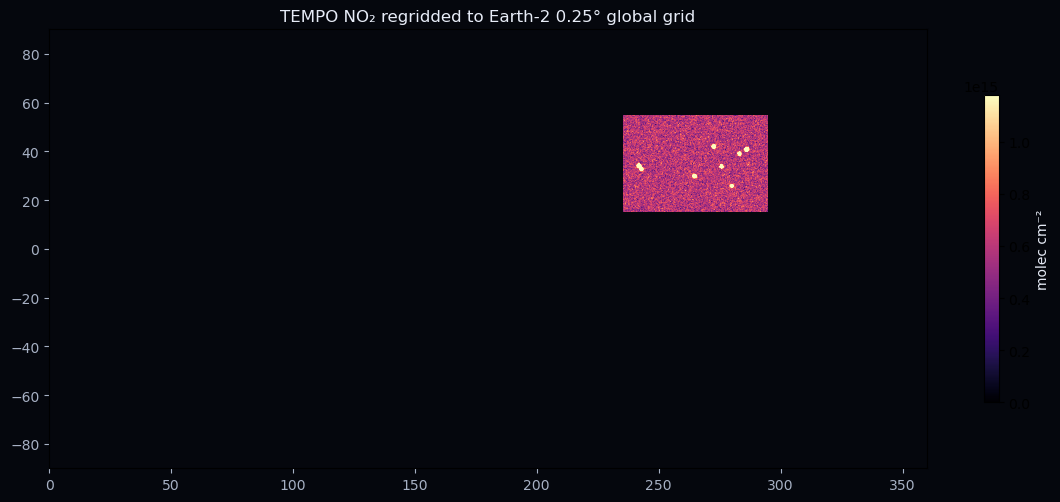

In [7]:
# Visual confirmation: pull the regridded global slice and plot it.
global_no2 = out[0, 0].numpy()
fig, ax = plt.subplots(figsize=(12, 5), facecolor="#05070d")
im = ax.imshow(
    global_no2,
    origin="upper",
    extent=[0, 360, -90, 90],
    cmap="magma",
    vmin=0,
    vmax=np.nanpercentile(global_no2, 99),
)
ax.set_title("TEMPO NO₂ regridded to Earth-2 0.25° global grid", color="#e7ecf7")
ax.set_facecolor("#05070d")
ax.tick_params(colors="#a7b1c4")
cbar = plt.colorbar(im, ax=ax, shrink=0.7)
cbar.set_label("molec cm⁻²", color="#e7ecf7")
plt.tight_layout(); plt.show()

## 4 · Toy ecological-response model

This is the **LEDT's reason to exist**: mapping atmospheric forcing to ecological response.

The real version will be a neural operator trained on decades of:
- TEMPO NO₂, O₃, HCHO, UV, SIF
- SERC GCReW eddy-covariance + chamber flux
- STRI ForestGEO census-derived canopy productivity
- MethaneSAT plume flux maps

For now we use a toy linear response that stands in for the API shape of the eventual model. This is **not science**; it exists only so downstream code can run end-to-end.


In [8]:
# Representative SERC / STRI sites (same as the website map)
FIELD_SITES = {
    "GCReW (SERC, tidal wetland)":  (38.8743, -76.5509, "wetland"),
    "Kirkpatrick Marsh (SERC)":     (38.874,  -76.546,  "wetland"),
    "Barro Colorado Island (STRI)": ( 9.1521, -79.8465, "forest"),
    "Agua Salud (STRI)":            ( 9.2167, -79.7333, "forest"),
    "Bocas del Toro mangrove (STRI)": (9.35,  -82.25,   "mangrove"),
}

# Toy ecological response sensitivity: ΔGPP per unit NO2 column.
# Sign conventions are just for illustration.
SENSITIVITY = {
    "wetland":  -0.12,   # elevated NO2 → small reduction in GPP + CH4 uptake
    "forest":   -0.35,   # dry-season O3 / NO2 dose → pronounced GPP damage
    "mangrove": -0.08,   # more buffered; methane feedback is the real concern
}


def site_sample_no2(grid_values, grid_lats, grid_lons_360, site_lat, site_lon):
    """Sample the regridded TEMPO field at a site; NaN if outside FOV."""
    lon360 = site_lon % 360
    i = int(np.abs(grid_lats - site_lat).argmin())
    j = int(np.abs(grid_lons_360 - lon360).argmin())
    return float(grid_values[i, j])


def ledt_response(tempo_global, sites=FIELD_SITES):
    lats = diagnostic._lat
    lons = diagnostic._lon
    report = []
    for name, (lat, lon, site_type) in sites.items():
        val = site_sample_no2(tempo_global, lats, lons, lat, lon)
        if np.isnan(val):
            report.append((name, site_type, None, None))
            continue
        # Normalize to 0..1 across the scene, then apply toy sensitivity.
        norm = val / np.nanpercentile(tempo_global, 99)
        delta_gpp = SENSITIVITY[site_type] * norm
        report.append((name, site_type, val, delta_gpp))
    return report


rows = ledt_response(global_no2)
print(f"{'Site':<38} {'Type':<10} {'NO2 col':>14}  {'ΔGPP (norm)':>12}")
print("-" * 82)
for name, site_type, val, dgpp in rows:
    vstr = "outside FOV" if val is None else f"{val:.2e}"
    dstr = "---" if dgpp is None else f"{dgpp:+.3f}"
    print(f"{name:<38} {site_type:<10} {vstr:>14}  {dstr:>12}")

Site                                   Type              NO2 col   ΔGPP (norm)
----------------------------------------------------------------------------------
GCReW (SERC, tidal wetland)            wetland          2.32e+15        -0.236
Kirkpatrick Marsh (SERC)               wetland          2.32e+15        -0.236
Barro Colorado Island (STRI)           forest        outside FOV           ---
Agua Salud (STRI)                      forest        outside FOV           ---
Bocas del Toro mangrove (STRI)         mangrove      outside FOV           ---


Out-of-FOV sites (STRI tropics) show `outside FOV` — exactly the gap that justifies the **TEMPO + MethaneSAT + DestinE** fusion design in Year 2. GCReW and other mid-Atlantic SERC sites fall squarely inside TEMPO's hemispheric staring region.


## 5 · Plugging into a real Earth-2 pipeline

When you're ready to run this against a real prognostic model — on a GPU — the call site looks like this. We don't execute it here because it downloads hundreds of MB of weights and GFS data; run it on a machine with an NVIDIA GPU.


In [9]:
EARTH2_PIPELINE_EXAMPLE = '''
# Real Earth-2 invocation — requires NVIDIA GPU + earth2studio install
from earth2studio.models.px import FCN3
from earth2studio.data import GFS
from earth2studio.io import ZarrBackend
import earth2studio.run as run

prognostic = FCN3.load_model(FCN3.load_default_package())
datasource = GFS()
io = ZarrBackend("outputs/fcn3_with_tempo.zarr")

# The LEDT diagnostic defined above drops into the built-in workflow
# exactly like PrecipitationAFNO or CorrDiff would.
run.diagnostic(
    ["2024-08-15T00:00:00"],
    nsteps=8,
    prognostic=prognostic,
    diagnostic=diagnostic,      # <-- TEMPONO2Diagnostic instance
    data=datasource,
    io=io,
)
'''
print(EARTH2_PIPELINE_EXAMPLE)


# Real Earth-2 invocation — requires NVIDIA GPU + earth2studio install
from earth2studio.models.px import FCN3
from earth2studio.data import GFS
from earth2studio.io import ZarrBackend
import earth2studio.run as run

prognostic = FCN3.load_model(FCN3.load_default_package())
datasource = GFS()
io = ZarrBackend("outputs/fcn3_with_tempo.zarr")

# The LEDT diagnostic defined above drops into the built-in workflow
# exactly like PrecipitationAFNO or CorrDiff would.
run.diagnostic(
    ["2024-08-15T00:00:00"],
    nsteps=8,
    prognostic=prognostic,
    diagnostic=diagnostic,      # <-- TEMPONO2Diagnostic instance
    data=datasource,
    io=io,
)



## 6 · Next milestones (post-seed-award)

From the LEDT proposal Section 5 (Pathway to Impact):

**Year 1 (2026–27)** — this notebook is a stand-in for the Innovation Design Lab prototype deliverable.
- Replace the synthetic fallback with routine `earthaccess` streaming of TEMPO L2 / L3.
- Swap nearest-neighbor regridding for conservative regridding via xESMF.
- Extend the diagnostic to multi-variable output: NO₂, O₃, HCHO, SIF, UV-AOD.
- Add a real CorrDiff-Bio downscaling step over a SERC-scale regional domain.

**Years 2–3** — TEMPO + MethaneSAT + DestinE fusion, AstroAI tipping-point detection on ecological time series, first end-to-end Methane-to-Mangrove run.

**Years 3–5** — LEDT as the sanctioned *Biological Extension* for Earth-2 / ESDT / DestinE, delivering a real-time, verifiable Carbon Audit linking orbital forcing to measured ecosystem response.
